# Data scientist take home technical test - Dhaou Idris

## 1. Annotation conversion

### Imports

In [53]:
import json 
import numpy as np 
import cv2
import matplotlib.pyplot as plt

### Création du mask

In [54]:
# Fonction pour extraire les dimensions de l'image à partir des annotations JSON

def get_dimensions(data):
    file_data = list(data.values())[0]
    regions = file_data['regions']
    
    max_x = 0
    max_y = 0

    for region in regions:
        shape = region['shape_attributes']
        if shape["name"]== "polygon":
            max_x = max(max(shape['all_points_x']), max_x)
            max_y = max(max(shape['all_points_y']), max_y)
    
    return max_x + 1, max_y + 1

In [55]:
# Fonction pour créer un masque à partir des annotations JSON

def create_mask(data):
    file_data = list(data.values())[0] 
    regions = file_data['regions']
    
    height, width = get_dimensions(data)

    mask = np.zeros((width, height), dtype=np.uint8)

    class_mapping = {   
    "unsure": 0,
    "bacteria": 1,
    "membrane": 2, }

    order = ['membrane','unsure',"bacteria"]

    # Dans l'ordre pour voir les membranes en premier, puis les zones "unsure", et enfin les bactéries.
    regions.sort(key=lambda r: order.index(r['region_attributes']['class']) 
                 if r['region_attributes']['class'] in order else -1)
    
    for region in regions:

        class_names = region['region_attributes']['class']

        class_id = class_mapping.get(class_names, 0)

        shape = region['shape_attributes']

        X = shape['all_points_x']
        Y = shape['all_points_y']

        points = np.array(list(zip(X, Y)), dtype=np.int32)
        points = points.reshape((-1, 1, 2))


        cv2.fillPoly(mask, [points], class_id)

    return mask

### Masque généré

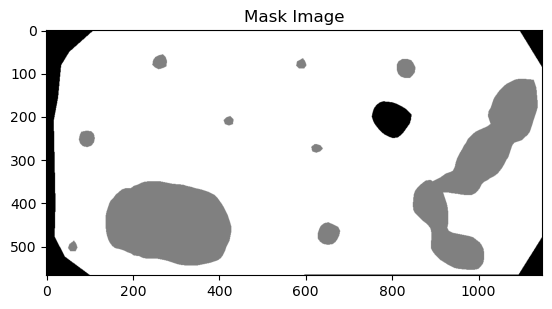

In [56]:
with open('./annotations.json') as f:
    data = json.load(f)

mask = create_mask(data)

mask = mask*100
cv2.imwrite("mask.png", mask)

plt.imshow(mask, cmap='gray')
plt.title('Mask Image')
plt.show()

## 2. Semantic segmentation strategy

### Introduction

Pour répondre à ce problème de segmentation multiclasse, je vais me baser sur mes travaux de recherche lors de projet de reconstruction holographique de bactéries. J'avais rencontré le même problème de déséquilibre de classe.

### Choix du modèle

Pour respecter la contrainte d'inférence ainsi que garantir une haute précision sur les bactéries, je recommande l'architecture U-Net:

- L'architecture Encoder-Decoder avec l'utilisation de blocs ResNet, est très efficace pour capturer à la fois le contexte global et les détails locaux.
- U-Net est l'état de l'art pour la segmentation biomédicale. L'inférence est largement inférieur à 1 seconde sur GPU en prenant un bloc ResNet-18 par exemple.
- A la différence de mon projet, ici, il faut modifier la dernière couche de convolution pour avoir 3 canaux de sortie avec une activation SoftMax. L'architecture choisie s'y adapte donc assez facilement.

### Fonction de coût

Le principal défi en segmentation de bactéries est le déséquilibre de classe. Basé sur mes expérimentations, je préconise l'utilisation d'une Loss composée de deux parties: 

$$ \mathcal{L}_{Total} = \omega_{dice} \mathcal{L}_{Dice} + \omega_{focal} \mathcal{L}_{Focal} $$

$$ \text{Focal Loss}(p_t) = - \alpha_t (1 - p_t)^\gamma \log(p_t) $$


L'adaptation de la Focal Loss au problème multiclasse est développée en partie 3. Pour la DiceLoss, on la sépare en 3 Dice Scores séparés pour calculer la binarité à chaque fois (ex: bactérie vs non-bactérie)

Cette fonction de coût est pertinente pour plusieurs raisons:
- Le facteur de modulation de la Focal Loss $(1 - p_t)^\gamma$ permet d'équilibrer les classes en forçant le modèle à se concentrer sur les exemples difficiles. $\alpha_t$ donne le poids de la classe pour gérer le déséquilibre
- La partie Dice Loss permet d'optimiser le recouvrement, ce qui est particulièrement utile pour conserver la cohérence strcturelle des bactéries.

Avec les hyperparamètres suivants :
* $\gamma = 2.0$ (Focalisation)
* $\omega_{dice} = 0.5$, $\omega_{focal} = 0.5$ (Pondération)
* $\alpha_t$



### Entrainement et Métriques

Pour valider scientifiquement le modèle, il ne faut pas se fier à l'accuracy globale.
On choisit les métriques suivantes:
- Dice Score par classe : Pour vérifier que la classe "Bactérie" est bien segmentée indépendamment des autres.

- Matrice de Confusion : Pour analyser les confusions spécifiques (ex: Bactérie vs Poussière).

- IoU (Intersection over Union) moyen.

- F1 Score.

Pour les données, on peut réaliser un split Train (80%) / Validation (20%)  pour surveiller l'overfitting.

Si le jeu de données est limité, une K-Fold Cross-Validation (k=5) assurera la robustesse des résultats.

### Stratégies d'amélioration

Si le modèle initial ne performe pas assez bien, je propose la démarche suivante : 
- Ajuster le paramètre de focalisation $\gamma$ (gamma) et les poids $\alpha_t$ de la Focal Loss. Mes expériences ont montré que pour des données très bruitées ou déséquilibrées, augmenter $\gamma$ (par exemple de 2.5 à 10) peut stabiliser l'apprentissage.
- Data Augmentation: on peut enrichir le dataset d'entraînement avec :Des rotations et flips. De l'injection de bruit gaussien (simulant le bruit de capteur).Des variations de contraste/luminosité pour imiter les conditions d'éclairage variables.
- Transfer Learning / Finetuning : Si le dataset réel est trop petit, pn peut  pré-entraîner les ResNet sur ImageNet, ou mieux, de faire du finetuning à partir d'un modèle entraîné sur des données synthétiques générées.

## 3. MultiFocalLoss

### Imports


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### Loss

In [58]:
class MultiClassFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma: float = 2.0, reduction: str = 'mean', ignore_index: int = -100):
        """
        alpha: list/np.array/tensor of length C (class weights) or None
        gamma: focal gamma
        reduction: 'mean' | 'sum' | 'none'
        ignore_index: index in targets to ignore
        """
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction
        self.ignore_index = ignore_index

        if alpha is None:
            self.register_buffer('alpha', None)
        else:
            a = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', a)

    def forward(self, inputs, targets):
            """
            Args:
                inputs: (Batch, Classes, Height, Width) - raw logits
                targets: (Batch, Height, Width) - class indices
                """
            if inputs.dim() != 4:
                raise ValueError("inputs should be (N, C, H, W)")
            N, C, H, W = inputs.shape
            logits = inputs.permute(0, 2, 3, 1).reshape(-1, C)          # (M, C)
            t = targets.view(-1)                                       # (M,)

            # pixel à ignorer
            if self.ignore_index is not None:
                valid_mask = (t != self.ignore_index)
                if valid_mask.sum() == 0:
                    return torch.tensor(0., device=inputs.device, dtype=inputs.dtype)
                logits = logits[valid_mask]
                t = t[valid_mask]

            # log softmax + gather log_pt
            log_probs = F.log_softmax(logits, dim=1)                   # (M_valid, C)
            log_pt = log_probs.gather(1, t.unsqueeze(1)).squeeze(1)    # (M_valid,)
            pt = log_pt.exp()                                          # (M_valid,)

            ce_loss = -log_pt                                          # positive
            focal_term = (1.0 - pt) ** self.gamma
            loss = focal_term * ce_loss                                # (M_valid,)

            # Application d'alpha si fourni
            if self.alpha is not None:
                at = self.alpha[t]                                    # (M_valid,)
                loss = loss * at

            if self.reduction == 'mean':
                return loss.mean()
            elif self.reduction == 'sum':
                return loss.sum()
            else:
                return loss

### Test

In [ ]:
logits = torch.tensor([[
    [ 3.0,  2.5, -1.0, -2.0],   # classe 0 (unsure)
    [ 0.2,  0.5,  3.0, -0.5],   # classe 1 (bactérie)
    [-1.0, -0.5,  0.1,  4.0]    # classe 2 (membrane)
]]).unsqueeze(-1)  # shape (1,3,4,1)

# On utilise bien les 3 classes
targets = torch.tensor([[0, 1, 2, 1]]).unsqueeze(-1)

print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)
print("Classes présentes:", torch.unique(targets))


# Cross Entropy
ce_pixel = F.cross_entropy(logits, targets, reduction='none')
print("\n--- Cross Entropy ---")
print("Loss pixel par pixel:", ce_pixel.view(-1))
print("Mean CE:", ce_pixel.mean().item())



# MultiClass Focal Loss
# On surpondère la bactérie (classe 1)

focal = MultiClassFocalLoss(
    alpha=[1.0, 2.0, 1.0],  # classe 1 (bactérie) pondérée x2
    gamma=2.0,
    reduction='none'
)

focal_pixel = focal(logits, targets)

print("\n--- Focal Loss ---")
print("Loss pixel par pixel:", focal_pixel.view(-1))
print("Mean Focal:", focal_pixel.mean().item())



# Comparaison détaillée

print("\nComparaison par pixel :")
for i in range(4):
    print(f"Pixel {i} | Target={targets.view(-1)[i].item()} "
          f"| CE={ce_pixel.view(-1)[i]:.4f} "
          f"| Focal={focal_pixel.view(-1)[i]:.6f}")

Logits shape: torch.Size([1, 3, 4, 1])
Targets shape: torch.Size([1, 4, 1])
Classes présentes: tensor([0, 1, 2])

--- Cross Entropy ---
Loss pixel par pixel: tensor([0.0762, 2.1698, 2.9708, 4.5135])
Mean CE: 2.4325671195983887

--- Focal Loss ---
Loss pixel par pixel: tensor([4.0942e-04, 3.4051e+00, 2.6740e+00, 8.8302e+00])
Mean Focal: 3.7274370193481445

Comparaison par pixel :
Pixel 0 | Target=0 | CE=0.0762 | Focal=0.000409
Pixel 1 | Target=1 | CE=2.1698 | Focal=3.405140
Pixel 2 | Target=2 | CE=2.9708 | Focal=2.673996
Pixel 3 | Target=1 | CE=4.5135 | Focal=8.830203


La focal Loss permet de réduire fortement la classe dominante (membrane) qui est souvent bien classée. La bactérie est la classe rare et difficile à classer, la focale ainsi que le poids alpha la renforce. Le gradient est également concentré sur les zones ambigues. On adapte initialement les poids alpha par l'inverse des fréquences puis on fine tune ces paramètres.